# Where and when does poly vs fourier say summer has length zero

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

## Read in both the poly fit data and fourier

In [2]:
# read in summer stats
input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/1961-2023_ALL_summer_stats.nc'
ds_f = xr.open_dataset(input_path)

input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_ALL_summer_stats.nc'
ds_p = xr.open_dataset(input_path)


In [3]:
ds_f, ds_p

(<xarray.Dataset> Size: 5GB
 Dimensions:       (lat: 721, lon: 1440, time: 63)
 Coordinates:
   * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
   * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
   * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
 Data variables:
     SummerStart   (time, lat, lon) float64 523MB ...
     SummerEnd     (time, lat, lon) float64 523MB ...
     SummerTmax    (time, lat, lon) float64 523MB ...
     SummerHeat    (time, lat, lon) float64 523MB ...
     SummerLength  (time, lat, lon) float64 523MB ...
     SummerRMSE    (time, lat, lon) float64 523MB ...
     SummerR2      (time, lat, lon) float64 523MB ...
     SummerMeanT   (time, lat, lon) float64 523MB ...
     SummerMeanHS  (time, lat, lon) float64 523MB ...
     lsm           (time, lat, lon) float64 523MB ...
     Coastal       (time, lat, lon) bool 65MB ...,
 <xarray.Dataset> Size: 5GB
 Dimensions:       (lat: 721, lon: 1440, t

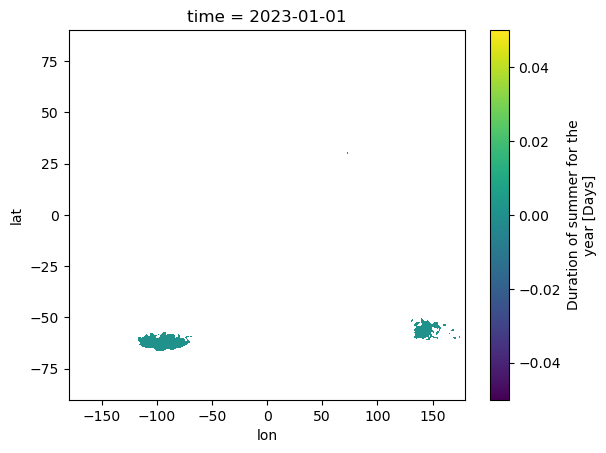

In [29]:
ds_f.SummerLength.sel(time="2023").where(ds_f.SummerLength == 0).plot()

## Will have to loop thru all lat/lon and gather all locations where Summerlength is zero across all years, I guess

In [56]:
gb = ds_f.SummerLength.where(ds_f.SummerLength == 0).groupby("time.year")
gb.map(np.count_nonzero)

AttributeError: 'int' object has no attribute 'dims'

In [58]:
yrs = np.arange(2006,2007,1)

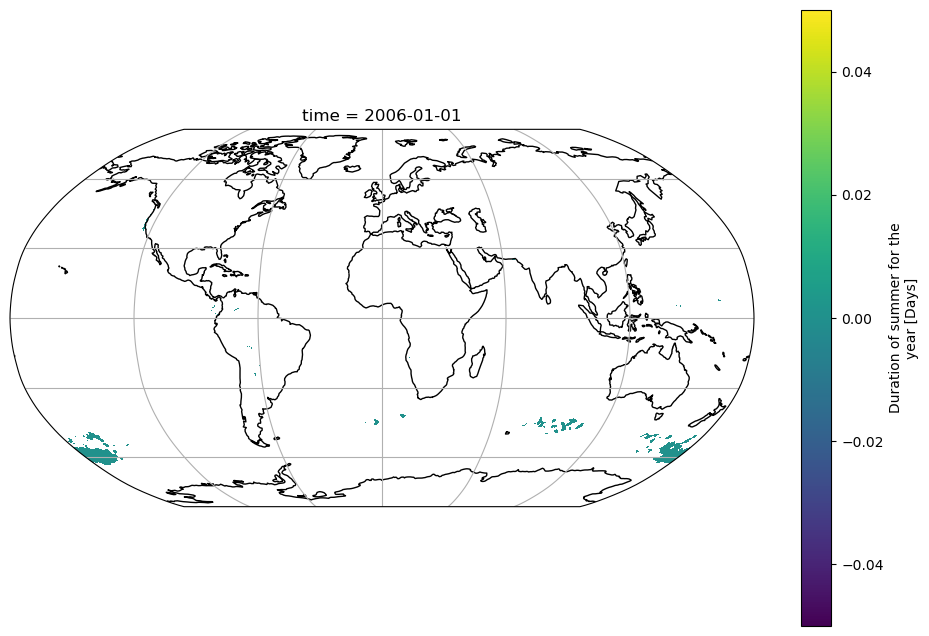

CPU times: user 1.31 s, sys: 114 ms, total: 1.43 s
Wall time: 1.42 s


In [59]:
%%time


plt.figure(figsize=(12,8))

for yr in yrs:
    # assign axis and def projection to use
    ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))
    
    # add coastlines and grid
    ax.coastlines()
    ax.gridlines()
    
    ds_f.SummerLength.sel(time=str(yr)).where(ds_f.SummerLength == 0).plot(
        ax=ax,
        transform=ccrs.PlateCarree(), # assign map projection
        #vmin=-0.7,
        #vmax=0.7, 
        #cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
        #cbar_kwargs={'shrink': 0.7}
    )


plt.show()

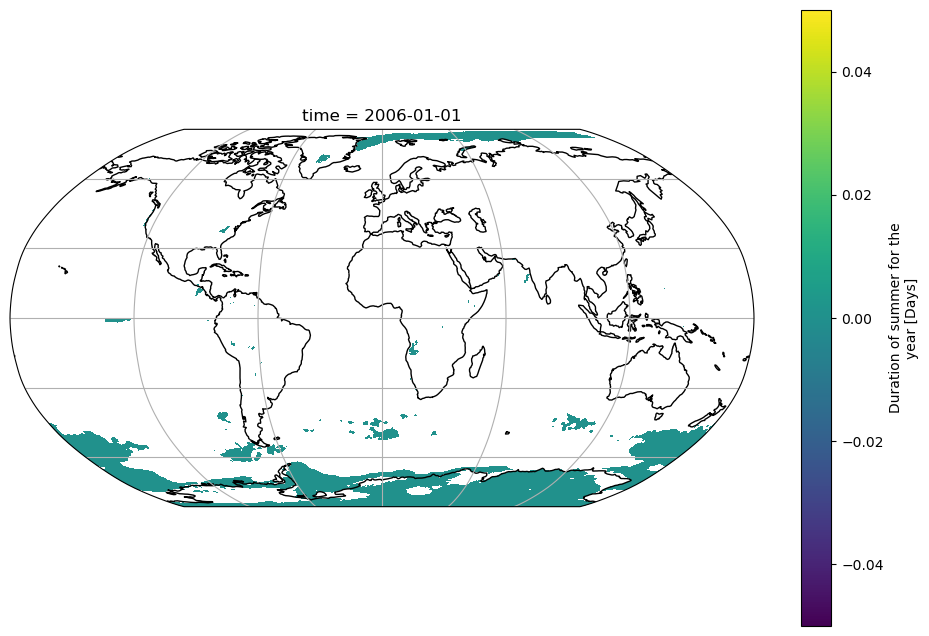

In [60]:
plt.figure(figsize=(12,8))

for yr in yrs:
    # assign axis and def projection to use
    ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))
    
    # add coastlines and grid
    ax.coastlines()
    ax.gridlines()
    
    ds_p.SummerLength.sel(time=str(yr)).where(ds_p.SummerLength == 0).plot(
        ax=ax,
        transform=ccrs.PlateCarree(), # assign map projection
        #vmin=-0.7,
        #vmax=0.7, 
        #cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
        #cbar_kwargs={'shrink': 0.7}
    )


plt.show()

In [16]:
#ds_f.SummerLength.where(ds_f.SummerLength == 0).groupby("time.year").count()
np.count_nonzero(ds_f.SummerLength.where(ds_f.SummerLength == 0)), np.count_nonzero(ds_p.SummerLength.where(ds_p.SummerLength == 0))

(63112929, 53040003)